In [4]:
!pip install pandas numpy scikit-learn xgboost lightgbm matplotlib


In [5]:

import pandas as pd
import datetime
import requests
import time
from random import randint
from time import sleep
import os
import requests
import numpy as np
import matplotlib.pyplot as plt

In [6]:
#Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

DATA_NFL_DIR = "/content/drive/MyDrive/NFL_Project/reports"
os.makedirs(DATA_NFL_DIR, exist_ok=True)

#Configure which seasons to pull
START_SEASON = 2019
END_SEASON = 2025

# PFR home/away marker column (contains '@' if the Winner played AWAY)
HA_COL = 'Unnamed: 5'

print(f"Configured seasons: {START_SEASON}–{END_SEASON}, HA_COL={HA_COL}")



Mounted at /content/drive
Configured seasons: 2019–2025, HA_COL=Unnamed: 5


In [8]:
SPORTSREF_PATH = "/content/drive/MyDrive/NFL_Project/reports/sportreft_week14_end_2025RS.csv"
OUT_CLEAN_PATH = "/content/drive/MyDrive/NFL_Project/reports/sportsref_week14_onward_2025RS_clean.csv"

# Helper Functions (reused from pipeline)
# ----------------------------
def assign_home_away_from_marker(row, ha_col: str) -> pd.Series:
    """
    Reconstruct home/away teams and scores using the PFR '@' marker:
      - If row[ha_col] == '@'  → Winner/tie was AWAY ⇒ Loser/tie is HOME
      - Else (blank/NaN)       → Winner/tie was HOME ⇒ Loser/tie is AWAY
    Returns: home_team, away_team, home_score, away_score
    """
    winner = row["Winner/tie"]
    loser  = row["Loser/tie"]
    pts_w  = row["PtsW"]
    pts_l  = row["PtsL"]

    winner_is_away = (str(row.get(ha_col, "")).strip() == "@")

    if winner_is_away:
        home_team, away_team = loser, winner
        home_score, away_score = pts_l, pts_w
    else:
        home_team, away_team = winner, loser
        home_score, away_score = pts_w, pts_l

    return pd.Series(
        [home_team, away_team, home_score, away_score],
        index=["home_team", "away_team", "home_score", "away_score"]
    )

def label_season_type_from_week(week_value) -> str:
    """
    Week is numeric for regular season (1..18) and a string label for playoffs.
    """
    try:
        _ = int(str(week_value))
        return "regular"
    except (TypeError, ValueError):
        return "postseason"

def to_int_or_na(week_value):
    """Convert Week to int when possible; otherwise <NA>."""
    try:
        return int(str(week_value))
    except (TypeError, ValueError):
        return pd.NA

# Load SportsRef file

df_raw = pd.read_csv(SPORTSREF_PATH)
df = df_raw.copy()

# Identify the '@' marker column (commonly "Unnamed: 5")
ha_col = None
candidate_cols = [c for c in df.columns if "Unnamed" in c or "@" in c or "marker" in c.lower()]
for c in candidate_cols:
    vals = df[c].astype(str).str.strip()
    if vals.isin(["@", "N"]).any() or (vals == "@").any():
        ha_col = c
        break

if ha_col is None and "Unnamed: 5" in df.columns:
    ha_col = "Unnamed: 5"

if ha_col is None:
    raise ValueError(
        "Could not find the home/away marker column (usually 'Unnamed: 5' containing '@'). "
        f"Columns found: {list(df.columns)}"
    )

# Season type + numeric week
df["season_type"] = df["Week"].apply(label_season_type_from_week)
df["week_num"] = df["Week"].apply(to_int_or_na)

# Keep regular season only
df = df[df["season_type"] == "regular"].copy()

# Convert week_num to int (safe now)
df["week_num"] = df["week_num"].astype("int64")

# Week 14 onwards
df = df[df["week_num"] >= 14].copy()

# Reconstruct home/away teams and scores using your helper
ha = df.apply(assign_home_away_from_marker, axis=1, ha_col=ha_col)
df = pd.concat([df, ha], axis=1)

# Neutral site flag (if present as 'N')
df["is_neutral_site"] = (df[ha_col].astype(str).str.strip() == "N").astype(int)

# Apply naming normalization
name_normalization = {
    "Washington Redskins": "Washington Commanders",
    "Washington Football Team": "Washington Commanders",
    "Houston Oilers": "Tennessee Titans",
    "St. Louis Rams": "Los Angeles Rams",
    "Cleveland Rams": "Los Angeles Rams",
    "Oakland Raiders": "Las Vegas Raiders",
    "Los Angeles Raiders": "Las Vegas Raiders",
    "San Diego Chargers": "Los Angeles Chargers",
    "Boston Patriots": "New England Patriots",
    "Titans of New York": "New York Jets",
    "Pittsburgh Pirates": "Pittsburgh Steelers",
    "Chicago Cardinals": "Arizona Cardinals",
    "St. Louis Cardinals": "Arizona Cardinals",
    "Phoenix Cardinals": "Arizona Cardinals",
    "Decatur Staleys": "Chicago Bears",
    "Chicago Staleys": "Chicago Bears",
    "Portsmouth Spartans": "Detroit Lions",
}

df["home_team_norm"] = df["home_team"].replace(name_normalization)
df["away_team_norm"] = df["away_team"].replace(name_normalization)

# Final cleaned output (game-level)
# ----------------------------
# If season column isn't present in this download, set it
if "season" not in df.columns:
    df["season"] = 2025

df_clean = df[
    ["season", "week_num", "home_team_norm", "away_team_norm", "home_score", "away_score", "is_neutral_site"]
].rename(columns={"week_num": "week", "home_score": "home_points", "away_score": "away_points"})

# Sanity prints (cleaning-only)
print("Raw shape:", df_raw.shape)
print("After regular-season filter + week>=14:", df.shape)
print("Clean shape:", df_clean.shape)
print(df_clean.head(10))

print("\nNull counts (key cols):")
print(df_clean[["home_team_norm", "away_team_norm", "home_points", "away_points"]].isna().sum())

# Save cleaned file
df_clean.to_csv(OUT_CLEAN_PATH, index=False)
print("\nSaved:", OUT_CLEAN_PATH)

Raw shape: (286, 14)
After regular-season filter + week>=14: (78, 24)
Clean shape: (78, 7)
     season  week        home_team_norm         away_team_norm  home_points  \
194    2025    14         Detroit Lions         Dallas Cowboys         44.0   
195    2025    14       Atlanta Falcons       Seattle Seahawks          9.0   
196    2025    14         Buffalo Bills     Cincinnati Bengals         39.0   
197    2025    14      Cleveland Browns       Tennessee Titans         29.0   
198    2025    14  Jacksonville Jaguars     Indianapolis Colts         36.0   
199    2025    14         New York Jets         Miami Dolphins         10.0   
200    2025    14     Minnesota Vikings  Washington Commanders         31.0   
201    2025    14  Tampa Bay Buccaneers     New Orleans Saints         20.0   
202    2025    14      Baltimore Ravens    Pittsburgh Steelers         22.0   
203    2025    14     Las Vegas Raiders         Denver Broncos         17.0   

     away_points  is_neutral_site  
194

In [11]:
PRED_PATH = "/content/drive/MyDrive/NFL_Project/reports/home_win_predictions_2025.csv"
CLEAN_PATH = "/content/drive/MyDrive/NFL_Project/reports/sportsref_week14_onward_2025RS_clean.csv"
OUT_EVAL_PATH = "/content/drive/MyDrive/NFL_Project/reports/week14_onward_eval_2025RS.csv"

pred = pd.read_csv(PRED_PATH)
clean = pd.read_csv(CLEAN_PATH)

required_pred_cols = {"home_team_norm", "away_team_norm", "home_win_proba"}
required_clean_cols = {
    "season", "week", "home_team_norm", "away_team_norm",
    "home_points", "away_points", "is_neutral_site"
}

missing_pred = required_pred_cols - set(pred.columns)
missing_clean = required_clean_cols - set(clean.columns)

if missing_pred:
    raise ValueError(f"Predictions file missing columns: {missing_pred}")
if missing_clean:
    raise ValueError(f"Clean SportsRef file missing columns: {missing_clean}")

# ----------------------------
# 3) Create actual outcome from points (ground truth)
clean = clean.copy()
clean["home_win_actual"] = (clean["home_points"] > clean["away_points"]).astype(int)

# ----------------------------
# 4) Merge predictions with actuals
eval_df = pred.merge(
    clean[[
        "season", "week", "home_team_norm", "away_team_norm",
        "home_points", "away_points", "is_neutral_site", "home_win_actual"
    ]],
    on=["home_team_norm", "away_team_norm"],
    how="left",
    validate="one_to_one"
)

# ----------------------------
# 5) Merge diagnostics (must be 0 missing)

n_total = len(eval_df)
n_missing = eval_df["home_win_actual"].isna().sum()

print(f"Total prediction rows: {n_total}")
print(f"Missing actual outcomes after merge: {int(n_missing)}")

if n_missing > 0:
    missing_keys = eval_df.loc[
        eval_df["home_win_actual"].isna(),
        ["home_team_norm", "away_team_norm"]
    ].drop_duplicates()
    print("\nKeys that did NOT merge (showing up to 20):")
    print(missing_keys.head(20))
    raise ValueError("Merge incomplete — fix naming or keys before continuing.")

# ----------------------------
# 6) Optional helper columns (useful for analysis)
eval_df["home_win_pred_label"] = (eval_df["home_win_proba"] >= 0.5).astype(int)
eval_df["pred_error"] = (eval_df["home_win_pred_label"] != eval_df["home_win_actual"]).astype(int)
eval_df["abs_prob_error"] = (eval_df["home_win_proba"] - eval_df["home_win_actual"]).abs()

# ----------------------------
# 7) Save evaluation dataframe
eval_df.to_csv(OUT_EVAL_PATH, index=False)
print(f"\nSaved evaluation file to: {OUT_EVAL_PATH}")

# Optional peek
display(eval_df.head(35))

Total prediction rows: 78
Missing actual outcomes after merge: 0

Saved evaluation file to: /content/drive/MyDrive/NFL_Project/reports/week14_onward_eval_2025RS.csv


,home_team_norm,away_team_norm,home_win_proba,season,week,home_points,away_points,is_neutral_site,home_win_actual,home_win_pred_label,pred_error,abs_prob_error
0,Detroit Lions,Dallas Cowboys,0.733999,2025,14,44.0,30.0,0,1,1,0,0.266001
1,Tampa Bay Buccaneers,New Orleans Saints,0.768856,2025,14,20.0,24.0,0,0,1,1,0.768856
2,New York Jets,Miami Dolphins,0.386330,2025,14,10.0,34.0,0,0,0,0,0.386330
3,Cleveland Browns,Tennessee Titans,0.786156,2025,14,29.0,31.0,0,0,1,1,0.786156
4,Baltimore Ravens,Pittsburgh Steelers,0.720033,2025,14,22.0,27.0,0,0,1,1,0.720033
5,Minnesota Vikings,Washington Commanders,0.639639,2025,14,31.0,0.0,0,1,1,0,0.360361
6,Buffalo Bills,Cincinnati Bengals,0.849717,2025,14,39.0,34.0,0,1,1,0,0.150283
7,Jacksonville Jaguars,Indianapolis Colts,0.371053,2025,14,36.0,19.0,0,1,0,1,0.628947
8,Atlanta Falcons,Seattle Seahawks,0.234343,2025,14,9.0,37.0,0,0,0,0,0.234343
9,Las Vegas Raiders,Denver Broncos,0.267810,2025,14,17.0,24.0,0,0,0,0,0.267810


# Columns Explination

Did the model get the direction right?
-  home_win_pred_label, pred_error

Was the model well-calibrated?
-  home_win_proba, abs_prob_error

Do contextual factors matter?
-  is_neutral_site, week

#Scatter pot
##Predicted Home Win Probability Vs Actual Outcome (Week 14+)

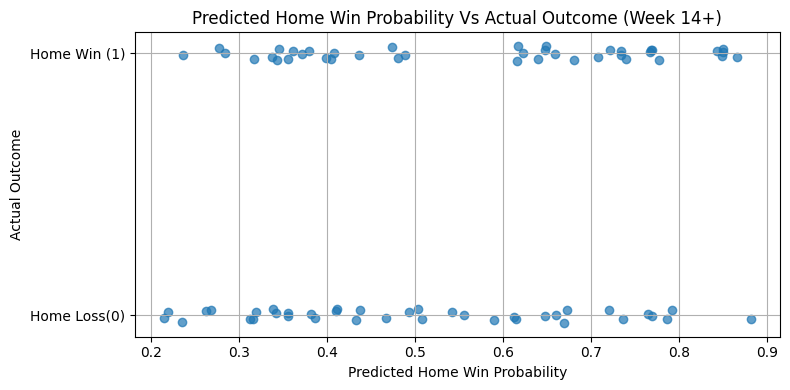

In [13]:
df = pd.read_csv(OUT_EVAL_PATH)

y_jitter = df["home_win_actual"] + np.random.uniform(-0.03,0.03,size=len(df))


plt.figure(figsize=(8,4))
plt.scatter(df["home_win_proba"], y_jitter, alpha=0.7)

plt.yticks([0,1], ["Home Loss(0)", "Home Win (1)"])
plt.xlabel("Predicted Home Win Probability")
plt.ylabel("Actual Outcome")
plt.title("Predicted Home Win Probability Vs Actual Outcome (Week 14+)")

plt.grid(True)
plt.tight_layout()
plt.show()

##This scatter plot compares the model’s predicted home win probability to the actual game outcome for NFL games played from Week 14 onward in the 2025 regular season. Each point represents one game.

- The x-axis shows the model’s confidence that the home team would win.
- The y-axis shows the realized outcome:
- 1 = home team won
- 0 = home team lost

A small amount of vertical jitter is added so overlapping points remain visible.

##Key Observations
- Higher predicted probabilities are generally associated with home wins, while lower probabilities are more often associated with home losses. This confirms that the model’s probability outputs are directionally meaningful rather than random.
- Several games with predicted probabilities above ~0.7 resulted in home losses. These high-confidence errors highlight the increased volatility of late-season NFL games.
- In the 0.5–0.6 probability band, home teams appear more likely to lose than win during this late-season window. This suggests that marginal home advantage may be less reliable late in the season, motivating a deeper calibration analysis.

#Calibration plot

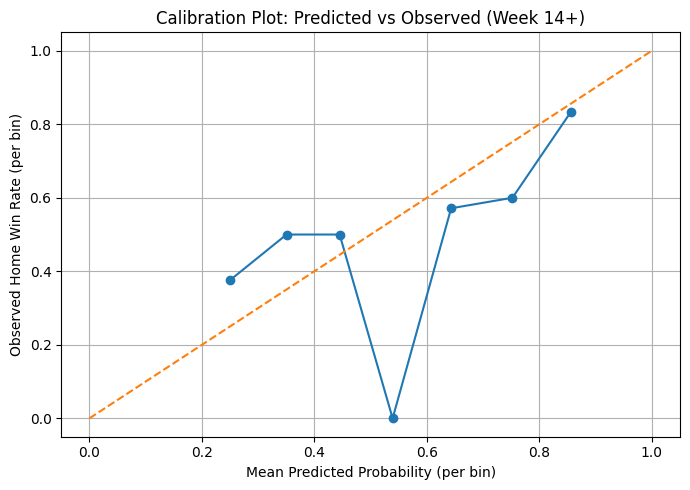

,prob_bin,mean_pred,win_rate,n
2,"(0.2, 0.3]",0.249308,0.375000,8
3,"(0.3, 0.4]",0.350477,0.500000,18
4,"(0.4, 0.5]",0.444880,0.500000,12
5,"(0.5, 0.6]",0.539094,0.000000,5
6,"(0.6, 0.7]",0.643151,0.571429,14
7,"(0.7, 0.8]",0.752098,0.600000,15
8,"(0.8, 0.9]",0.855947,0.833333,6


In [14]:
# Bins 0.0 to 1.0 by 0.1
bins = np.linspace(0, 1, 11)
df["prob_bin"] = pd.cut(df["home_win_proba"], bins=bins, include_lowest=True)

calib = (
    df.groupby("prob_bin", observed=False)
      .agg(
          mean_pred=("home_win_proba", "mean"),
          win_rate=("home_win_actual", "mean"),
          n=("home_win_actual", "size")
      )
      .reset_index()
)

# Keep non-empty bins
calib = calib[calib["n"] > 0].copy()

# Plot
plt.figure(figsize=(7, 5))
plt.plot(calib["mean_pred"], calib["win_rate"], marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")  # perfect calibration

plt.xlabel("Mean Predicted Probability (per bin)")
plt.ylabel("Observed Home Win Rate (per bin)")
plt.title("Calibration Plot: Predicted vs Observed (Week 14+)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Table output
calib

The calibration plot compares predicted home win probabilities to observed home win rates using 0.10-wide probability bins. While higher predicted probabilities generally correspond to higher home win rates, the model is not perfectly calibrated in the late-season window. The most notable deviation occurs in the 0.5–0.6 range, where the model predicted a slight home advantage (~54%) but home teams failed to win any of the games in that bin. This confirms the pattern observed in the scatter plot and suggests that marginal home advantage was unreliable late in the season.

At lower probability ranges (0.2–0.4), home teams won more often than predicted, indicating underconfidence, while higher probability bins (0.7+) show mild overconfidence. Overall, the model captures meaningful directional signal but exhibits calibration drift in late-season games, likely reflecting increased variance from injuries, weather, and playoff incentives rather than a systematic modeling error.

#Histogram

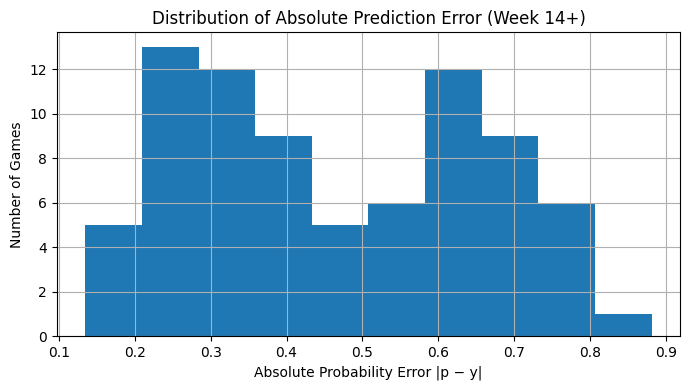

In [15]:
# Histogram of absolute probability error
plt.figure(figsize=(7, 4))
plt.hist(df["abs_prob_error"], bins=10)

plt.xlabel("Absolute Probability Error |p − y|")
plt.ylabel("Number of Games")
plt.title("Distribution of Absolute Prediction Error (Week 14+)")
plt.grid(True)
plt.tight_layout()
plt.show()

This histogram shows the distribution of absolute probability error across late-season games, measuring how far predicted probabilities deviated from actual outcomes. Most games fall in the lower-to-mid error range (approximately 0.2–0.5), indicating that even when predictions were incorrect, the model’s confidence was often moderate rather than extreme.

A smaller number of games exhibit large errors (above ~0.6), corresponding to high-confidence misses where the model strongly favored the home team but the outcome went the other way. These cases align with the calibration results and reflect increased late-season volatility rather than systematic failure. Overall, the error distribution suggests the model generally avoids extreme miscalibration, with most errors driven by uncertainty in marginal or volatile matchups.

#Final analysis

##Final Analysis Summary

Across the full evaluation, the model demonstrates meaningful predictive signal while also revealing the inherent volatility of late-season NFL games. On the held-out 2025 test set, the model achieved a ROC-AUC of ~0.72, indicating strong ranking ability, while the Brier score (~0.21) confirms that probability estimates remain reasonably calibrated overall. However, when restricting evaluation to Week 14 onward, performance metrics decline (accuracy ~54%, ROC-AUC ~0.60), reflecting a more challenging prediction regime rather than a fundamental model failure.

Visual analysis reinforces this conclusion. The scatter plot confirms that higher predicted probabilities generally correspond to home wins, validating directional signal. The calibration plot confirms the pattern observed in the scatter plot and suggests that marginal home advantage was unreliable late in the season, particularly in the 0.5–0.6 probability range where home teams underperformed model expectations. The error distribution further shows that most mistakes were moderate, with a smaller number of high-confidence misses driven by late-season uncertainty.

##Final Thoughts on Volatility and Interpretation

It is fair—and appropriate—to attribute much of this late-season degradation to NFL volatility rather than model weakness. Factors such as injuries, playoff incentives, rest strategies, weather, and matchup-specific game planning introduce structural noise that is difficult to capture fully in historical data. Outcomes like the Carolina Panthers and Pittsburgh Steelers reaching the Wild Card despite weaker season-long indicators are consistent with the patterns observed in this analysis.

This volatility also provides insight into why sports betting remains profitable for sportsbooks despite sophisticated models and analytics. While probabilistic models can identify edges and rank outcomes, short-horizon events are still heavily influenced by randomness, situational dynamics, and strategic decisions. In other words, the math is informative—but it does not eliminate uncertainty. This project highlights that reality clearly: strong models improve decision-making, but they cannot remove luck from the game.